# NISAR GCOV — Quality Control and Statistics


# 07 — QC, Statistics, Masks & Dynamic Polarization

The same statistics and masking code runs whether this product is dual-pol or quad-pol — it discovers which terms exist rather than assuming HH/HV up front.

The GCOV `mask` dataset is read on the same subset as everything else, and `MASK == 0` pixels are set to NaN in each diagonal channel before any statistic is computed or anything is plotted -- invalid pixels never skew a mean, a percentile, or a first-look map.

In [1]:
from pathlib import Path
from nisar_utils.bootstrap import setup_workshop
WORKSHOP_ROOT = setup_workshop()

from nisar_utils.config import load_config
from nisar_utils.gcov import read_window
from nisar_utils.workflow import (
    build_profile, resolve_frequency, resolve_terms,
    resolve_aoi, resolve_window
)

cfg = load_config()
NISAR_FILE = Path(cfg["nisar_file"])
profile = build_profile(cfg)
freq = resolve_frequency(cfg, profile)
terms, diagonal_terms, off_diagonal_terms = resolve_terms(profile, freq)

print("File:", NISAR_FILE)
print("SAR family:", profile.sar_family)
print("Band:", profile.band)
print("Level:", profile.product_level)
print("Product:", profile.product_type)
print("GCOV root:", profile.gcov_root)
print("Frequency:", freq)
print("Polarization:", profile.polarization_channels)


File: E:\NISAR_L2_PR_GCOV_030_005_D_075_2005_QPDH_A_20260906T132343_20260906T132418_P05023_N_F_J_001.h5
SAR family: LSAR
Band: L
Level: L2
Product: GCOV
GCOV root: /science/LSAR/GCOV
Frequency: frequencyA
Polarization: ['HH', 'HV', 'VH', 'VV']


## Geographic context

Same footprint as before — this module doesn't touch geolocation, just confirms we're still on the same scene.

In [2]:
from nisar_utils.gcov import open_gcov,get_grid_coordinates
from nisar_utils.mapping import scene_extent_wgs84,plot_scene_overview,folium_scene_map
grid=f"{profile.gcov_root}/grids/{freq}"
with open_gcov(NISAR_FILE) as f: _x,_y=get_grid_coordinates(f,grid)
scene_bounds,_=scene_extent_wgs84(_x,_y,profile.epsg)
print("Scene WGS84 extent:",scene_bounds)


Scene WGS84 extent: {'lon_min': 77.64369698711057, 'lat_min': 25.16424365403812, 'lon_max': 81.19488053590649, 'lat_max': 28.287894586312564}


(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'NISAR LSAR frequencyA — Geographic Context'}, xlabel='Longitude (°E)', ylabel='Latitude (°N)'>)

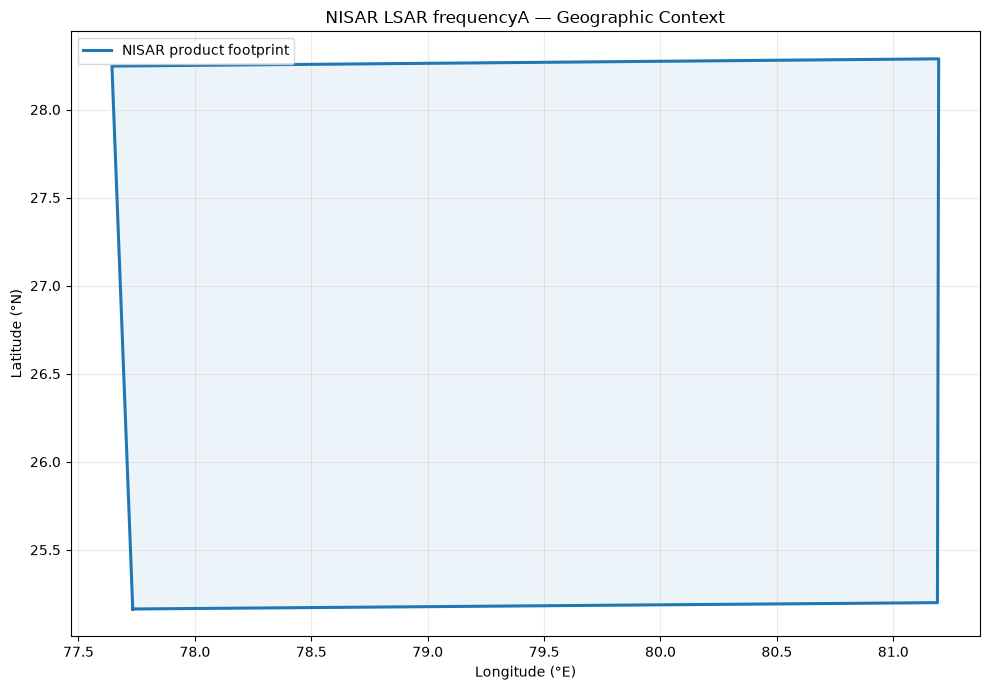

In [3]:
plot_scene_overview(_x,_y,profile.epsg,title=f"NISAR {profile.sar_family} {freq} — Geographic Context")


In [4]:
m=folium_scene_map(_x,_y,profile.epsg,title="NISAR scene — geographic context")
m


In [5]:
import numpy as np
from nisar_utils.gcov import open_gcov, read_window, read_gcov_mask, apply_gcov_mask
from nisar_utils.spatial import coordinate_to_index
from nisar_utils.statistics import summary, robust_limits

grid = f"{profile.gcov_root}/grids/{freq}"

with open_gcov(NISAR_FILE) as f:
    x, y = f[f"{grid}/xCoordinates"][:], f[f"{grid}/yCoordinates"][:]

    (r0, r1, c0, c1), _ = resolve_window(
        x, y, cfg, coordinate_to_index_func=coordinate_to_index
    )

    expected_shape = (r1 - r0, c1 - c0)
    print("Module 06 subset hand-off:")
    print("  Rows   :", r0, r1)
    print("  Columns:", c0, c1)
    print("  Size   :", expected_shape[0], "rows x", expected_shape[1], "columns")

    # Read the GCOV validity mask once, on the same subset, and apply it to
    # each diagonal channel before any statistic is computed.
    invalid_mask, mask_arr = read_gcov_mask(f, grid, r0, r1, c0, c1)
    print("\nGCOV MASK:")
    print("  MASK == 0 (invalid):", f"{int(np.count_nonzero(invalid_mask)):,}")
    print("  MASK != 0 (valid)  :", f"{int(np.count_nonzero(~invalid_mask)):,}")

    for term in (diagonal_terms or terms[:1]):
        path = f"{grid}/{term}"
        arr = read_window(f, path, r0, r1, c0, c1)
        if arr.shape != expected_shape:
            raise RuntimeError(
                f"Unexpected GCOV subset shape for {term}: {arr.shape}; "
                f"expected {expected_shape}"
            )
        arr_masked = apply_gcov_mask(arr, term, invalid_mask)
        masked_count = int(np.count_nonzero(np.isnan(arr_masked))) if term in ("HHHH", "HVHV", "VVVV", "VHVH", "RHRH", "RVRV") else 0

        print("\nTerm:", term)
        print("Shape:", arr.shape)
        if masked_count:
            print("MASK=0 pixels set to NaN:", f"{masked_count:,}")
        print("Summary (mask applied):", summary(arr_masked))
        print("Robust limits (mask applied):", robust_limits(arr_masked))

Module 06 subset hand-off:
  Rows   : 7056 12653
  Columns: 6459 11507
  Size   : 5597 rows x 5048 columns

GCOV MASK:
  MASK == 0 (invalid): 3,043,761
  MASK != 0 (valid)  : 25,209,895

Term: HHHH
Shape: (5597, 5048)
MASK=0 pixels set to NaN: 3,043,761
Summary (mask applied): {'count': 25209895, 'min': 0.0013820230960845947, 'max': 2849.53125, 'mean': 0.2633051761257445, 'std': 1.8098212174236918}
Robust limits (mask applied): (0.013808965682983398, 0.96990966796875)

Term: HVHV
Shape: (5597, 5048)
MASK=0 pixels set to NaN: 3,043,761
Summary (mask applied): {'count': 25209895, 'min': 0.0005724206566810608, 'max': 109.1796875, 'mean': 0.029955002779041798, 'std': 0.06066714149624528}
Robust limits (mask applied): (0.0034849345684051514, 0.11484146118164062)

Term: VHVH
Shape: (5597, 5048)
MASK=0 pixels set to NaN: 3,043,761
Summary (mask applied): {'count': 25209895, 'min': 0.00048099830746650696, 'max': 112.9736328125, 'mean': 0.031085105418066618, 'std': 0.05989059791480512}
Robust l

In [6]:
print("\nModule 07 STATUS: PASS")



Module 07 STATUS: PASS


GCOV term : HHHH
Original subset: (5597, 5048)
Map display subset: (1120, 1010)
Downsampling: 5 × 5
Map extent: {'lon_min': 78.98272023316946, 'lat_min': 25.989841527449826, 'lon_max': 80.00809889628364, 'lat_max': 27.01048272142923}



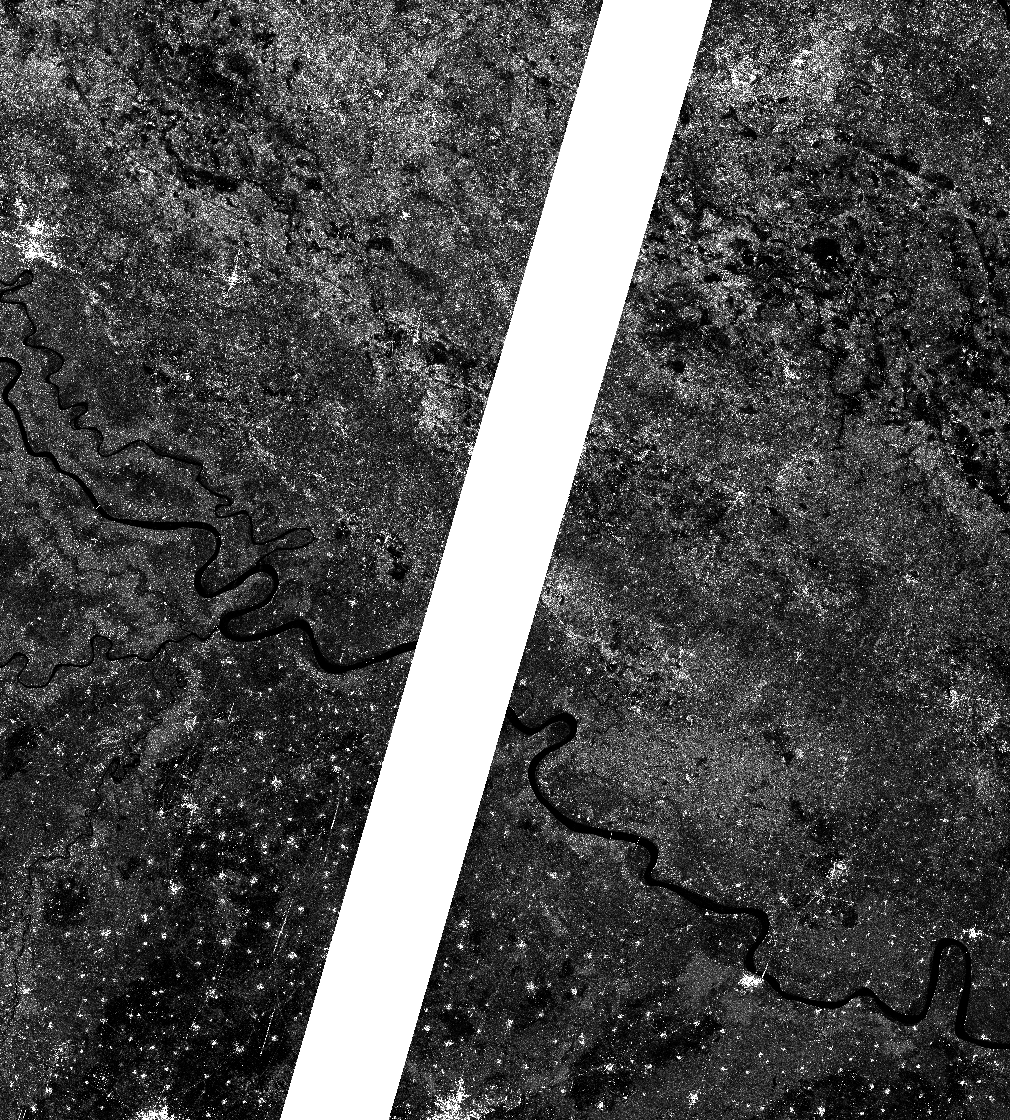

In [7]:
## First-look GCOV map
# Display a downsampled first-look map to avoid creating
# an extremely large browser/PNG object.

from nisar_utils.mapping import scene_extent_wgs84, raster_map
from IPython.display import display
import numpy as np

try:
    term0 = (diagonal_terms or terms)[0]

    with open_gcov(NISAR_FILE) as f:
        grid = f"{profile.gcov_root}/grids/{freq}"

        x0 = f[f"{grid}/xCoordinates"][:]
        y0 = f[f"{grid}/yCoordinates"][:]

        # Read the selected Module 06 native subset
        arr0 = read_window(
            f,
            f"{grid}/{term0}",
            r0, r1, c0, c1
        )

        # Apply the same GCOV MASK==0 -> NaN rule used for the statistics
        # above, so the first-look map does not show invalid ground as if
        # it were valid data.
        invalid_mask0, _ = read_gcov_mask(f, grid, r0, r1, c0, c1)
        arr0 = apply_gcov_mask(arr0, term0, invalid_mask0)

    print("GCOV term :", term0)
    print("Original subset:", arr0.shape)

    # ------------------------------------------------------------
    # Downsample for interactive map display
    # ------------------------------------------------------------
    max_pixels = 1200

    row_step = max(1, int(np.ceil(arr0.shape[0] / max_pixels)))
    col_step = max(1, int(np.ceil(arr0.shape[1] / max_pixels)))

    arr_map = arr0[::row_step, ::col_step]
    x_map = x0[c0:c1:col_step]
    y_map = y0[r0:r1:row_step]

    print("Map display subset:", arr_map.shape)
    print("Downsampling:", row_step, "×", col_step)

    # ------------------------------------------------------------
    # Geographic extent of the displayed subset
    # ------------------------------------------------------------
    subset_bounds, _ = scene_extent_wgs84(
        x_map,
        y_map,
        profile.epsg
    )

    print("Map extent:", subset_bounds)

    # ------------------------------------------------------------
    # Convert Module 06 AOI schema to mapping schema
    # ------------------------------------------------------------
    aoi_cfg = cfg.get("default_aoi") or cfg.get("aoi")

    if aoi_cfg:
        if all(k in aoi_cfg for k in
               ("lon_min", "lon_max", "lat_min", "lat_max")):

            map_aoi = {
                "lon_min": float(aoi_cfg["lon_min"]),
                "lon_max": float(aoi_cfg["lon_max"]),
                "lat_min": float(aoi_cfg["lat_min"]),
                "lat_max": float(aoi_cfg["lat_max"]),
            }

        elif all(k in aoi_cfg for k in
                 ("xmin", "xmax", "ymin", "ymax")):

            map_aoi = {
                "lon_min": float(aoi_cfg["xmin"]),
                "lon_max": float(aoi_cfg["xmax"]),
                "lat_min": float(aoi_cfg["ymin"]),
                "lat_max": float(aoi_cfg["ymax"]),
            }

        else:
            map_aoi = None

    else:
        map_aoi = None

    # ------------------------------------------------------------
    # Generate interactive first-look map
    # ------------------------------------------------------------
    first_map = raster_map(
        x_map,
        y_map,
        profile.epsg,
        arr_map,
        subset_bounds,
        title=f"GCOV {freq} — {term0}",
        aoi=map_aoi,
        cmap="gray"
    )

    display(first_map)

except Exception as e:
    print("First-look GCOV map unavailable:")
    print(type(e).__name__, ":", e)